In [2]:


import numpy as np
import sklearn
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

numpy: 2.1.3
sklearn: 1.6.1


In [3]:
# ============================================================
# Cell 1 — Hämta MNIST-datan
# ============================================================
# Vi använder fetch_openml för att ladda ner MNIST-datasetet.
# MNIST består av 70 000 handskrivna siffror (0-9).
# Varje bild är 28x28 pixlar = 784 värden per bild.
#
# Parametrar:
#   - "mnist_784" : namnet på datasetet
#   - version=1   : säkerställer att vi får rätt version
#   - cache=True  : sparar datan lokalt så vi slipper ladda ner igen
#   - as_frame=False : returnerar numpy-arrays istället för DataFrame
# ============================================================

In [4]:
# Cell 1 — Hämta datan
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, cache=True, as_frame=False)
print(mnist.DESCR)  # Läs om datasetet

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [5]:
# ============================================================
# Cell 2 — Plocka ut features och labels
# ============================================================
# mnist["data"] innehåller alla 70 000 bilder.
# Varje rad är en bild med 784 värden (28x28 pixlar tillplattade).
# mnist["target"] innehåller etiketterna, dvs vilken siffra
# varje bild föreställer. Etiketterna är strängar ("0"-"9").
#
# X = input (det modellen ska lära sig av)
# y = output (det rätta svaret)
# ============================================================


In [6]:
# Cell 2 — Plocka ut features och labels
X = mnist["data"]   
y = mnist["target"]  

print("X shape:", X.shape)  
print("Y shape:", y.shape)  
print("Exempel på label:", y[0])

X shape: (70000, 784)
Y shape: (70000,)
Exempel på label: 5


In [7]:
# ============================================================
# Cell 3 — Dela upp i träning och test
# ============================================================
# MNIST är redan sorterat så att de första 60 000 bilderna
# används för träning och de sista 10 000 för test.
# Vi följer denna standard för att kunna jämföra med andra.
#
# Träningsdata: modellen lär sig från denna
# Testdata: används BARA för slututvärdering, aldrig under träning
# ============================================================

In [8]:
# Cell 3 — Dela upp i träning och test (standard för MNIST)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("Träning:", X_train.shape)
print("Test:", X_test.shape)

Träning: (60000, 784)
Test: (10000, 784)


In [9]:
# ============================================================
# Cell 4 — Visualisera 10 exempel från träningsdatan
# ============================================================
# För att förstå datan bättre visualiserar vi 10 bilder.
# Vi ritar om varje bild från 784 värden till 28x28 pixlar
# med hjälp av reshape(28, 28).
# cmap="gray" gör att bilden visas i gråskala.
# ============================================================


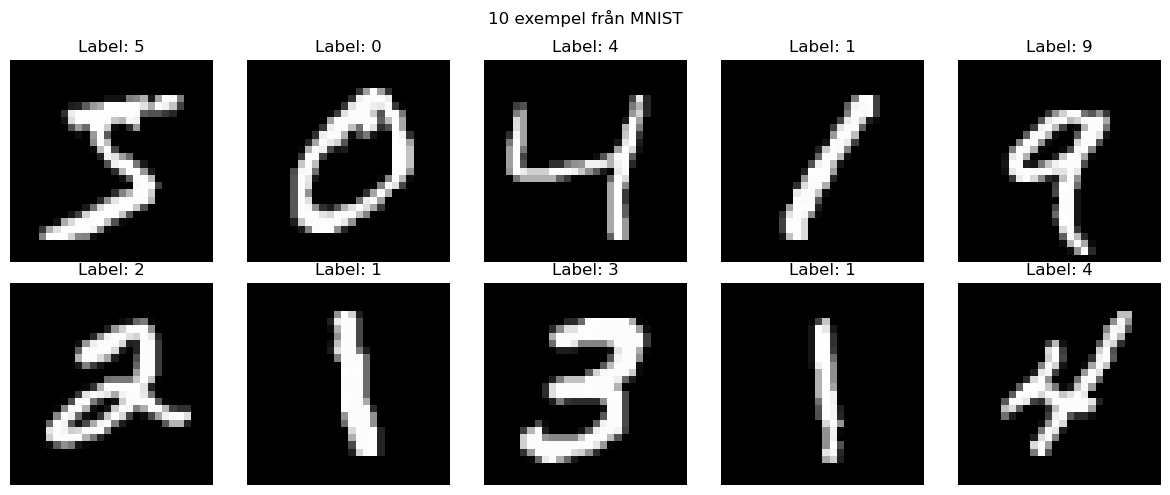

In [10]:
# Cell 4 — Visualisera 10 exempel
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.suptitle("10 exempel från MNIST")
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Cell 5 — Kolla klassfördelning
# ============================================================
# Vi kontrollerar hur många bilder det finns av varje siffra (0-9).
# En jämn fördelning är viktigt — om en siffra har mycket fler
# bilder kan modellen bli partisk mot den siffran.
# np.unique returnerar unika värden och hur många gånger de förekommer.
# ============================================================

In [12]:
# Cell 5 — Kolla klassfördelning 
import numpy as np

unika, antal = np.unique(y_train, return_counts=True)
for siffra, n in zip(unika, antal):
    print(f"Siffra {siffra}: {n} bilder")

Siffra 0: 5923 bilder
Siffra 1: 6742 bilder
Siffra 2: 5958 bilder
Siffra 3: 6131 bilder
Siffra 4: 5842 bilder
Siffra 5: 5421 bilder
Siffra 6: 5918 bilder
Siffra 7: 6265 bilder
Siffra 8: 5851 bilder
Siffra 9: 5949 bilder


In [13]:
# ============================================================
# Cell 6 — Normalisera pixelvärdena
# ============================================================
# Pixelvärden går från 0 till 255 (gråskala).
# Vi delar med 255 så att alla värden hamnar mellan 0 och 1.
# Detta kallas normalisering och är viktigt av två skäl:
#   1. Modeller tränar snabbare med normaliserade värden
#   2. Alla features får samma skala, ingen dominerar
# Vi normaliserar BÅDE tränings- och testdata på samma sätt.
# ============================================================

In [14]:
# Cell 6 — Normalisera pixelvärdena (viktigt innan träning!)
# Pixlar går från 0-255, vi delar med 255 så de hamnar mellan 0 och 1
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

print("Min:", X_train_norm.min())   # Ska visa 0.0
print("Max:", X_train_norm.max())   # Ska visa 1.0

Min: 0.0
Max: 1.0


In [15]:
# ============================================================
# Cell 7 — Träna Modell 1: Logistisk Regression
# ============================================================
# Logistisk Regression är en enkel linjär modell för klassificering.
# Trots namnet används den för klassificering, inte regression.
# Den beräknar sannolikheten att en bild tillhör varje klass (0-9)
# och väljer den klass med högst sannolikhet.
#
# Parametrar:
#   - max_iter=1000  : antal steg modellen får för att konvergera
#   - random_state=42: gör resultaten reproducerbara
# ============================================================

In [16]:
# Cell 7 — Träna Logistisk Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_norm, y_train)

print("Träning klar!")

Träning klar!


In [17]:
# ============================================================
# Cell 8 — Utvärdera Logistisk Regression på träningsdata
# ============================================================
# accuracy_score beräknar andelen korrekta prediktioner.
# Vi utvärderar först på träningsdata för att se hur bra
# modellen lärt sig — men detta är inte det slutliga resultatet.
# Det slutliga testet görs på testdata som modellen aldrig sett.
# ============================================================

In [18]:
# Cell 8 — Utvärdera på träningsdatan
from sklearn.metrics import accuracy_score

y_pred_train = log_reg.predict(X_train_norm)
accuracy_train = accuracy_score(y_train, y_pred_train)

print(f"Accuracy på träningsdata: {accuracy_train:.4f}")

Accuracy på träningsdata: 0.9390


In [19]:
# ============================================================
# Cell 9 — Testa på ett enskilt exempel
# ============================================================
# Vi testar modellen på en enskild bild för att se hur det fungerar.
# reshape(1, -1) omvandlar bilden till rätt format för predict().
# Vi visualiserar bilden och jämför modellens gissning med rätt svar.
# Prova ändra index till olika värden för att testa fler bilder.
# ============================================================

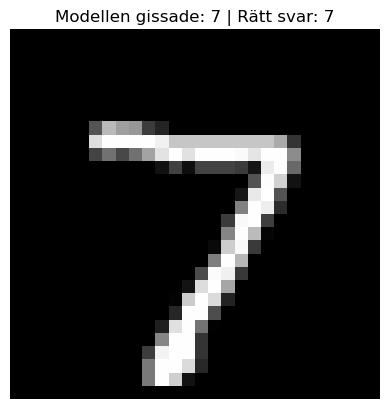

In [20]:
# Cell 9 — Testa på ett enskilt exempel
import matplotlib.pyplot as plt

index = 0  
bild = X_test_norm[index].reshape(1, -1)
prediktion = log_reg.predict(bild)

plt.imshow(X_test_norm[index].reshape(28, 28), cmap="gray")
plt.title(f"Modellen gissade: {prediktion[0]} | Rätt svar: {y_test[index]}")
plt.axis("off")
plt.show()

In [21]:
#Modell 2: Random Forest 

In [22]:
# ============================================================
# Cell 10 — Träna Modell 2: Random Forest
# ============================================================
# Random Forest bygger många beslutsträd (n_estimators=100)
# och låter dem rösta om vilket svar som är rätt.
# Fördelen är att den ofta presterar bra utan mycket tuning.
# Nackdelen är att den kan overfitta — lära sig träningsdatan
# utantill — vilket vi kommer att se i resultaten.
#
# Parametrar:
#   - n_estimators=100 : antal träd i skogen
#   - random_state=42  : reproducerbara resultat
# ============================================================

In [23]:
# Cell 10 — Träna Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_norm, y_train)

print("Träning klar!")

Träning klar!


In [24]:
# ============================================================
# Cell 11 — Utvärdera Random Forest på träningsdata
# ============================================================
# Vi beräknar accuracy för Random Forest på träningsdata.
# OBS: 100% accuracy på träningsdata är ett varningstecken —
# det tyder på overfitting. Modellen har lärt sig datan
# utantill istället för att generalisera.
# Cross-validation i nästa steg avslöjar den verkliga prestandan.
# ============================================================


In [25]:
# Cell 11 — Utvärdera på träningsdata
y_pred_rf_train = rf_model.predict(X_train_norm)
accuracy_rf_train = accuracy_score(y_train, y_pred_rf_train)

print(f"Accuracy Random Forest på träningsdata: {accuracy_rf_train:.4f}")

Accuracy Random Forest på träningsdata: 1.0000


In [26]:
# ============================================================
# Cell 12 — Jämför Logistisk Regression och Random Forest
# ============================================================
# Vi jämför de två modellernas accuracy på träningsdata.
# Random Forest visar 100% vilket bekräftar overfitting.
# Logistisk Regression visar en mer realistisk siffra (~93%).
# Träningsdata accuracy är dock inte tillräcklig för att
# välja bästa modell — det kräver cross-validation.
# ============================================================


In [27]:
# Cell 12 — Jämför modellerna hittills
print("=== Jämförelse modeller (träningsdata) ===")
print(f"Logistisk Regression : {accuracy_train:.4f}")
print(f"Random Forest        : {accuracy_rf_train:.4f}")

=== Jämförelse modeller (träningsdata) ===
Logistisk Regression : 0.9390
Random Forest        : 1.0000


In [28]:
# Modell 3: KNN

In [29]:
# ============================================================
# Cell 13 — Träna Modell 3: KNN (K-Nearest Neighbors)
# ============================================================
# KNN är en enkel modell som klassificerar en ny bild
# genom att titta på de K närmaste bilderna i träningsdatan
# och rösta om vilket svar som är vanligast.
# Intuitionen: om de 3 närmaste grannarna är siffran 7,
# så är den nya bilden troligen också en 7.
#
# Parametrar:
#   - n_neighbors=3 : tittar på de 3 närmaste grannarna
#
# OBS: KNN tränar snabbt men prediktionen är långsam (~10 min)
# eftersom den jämför varje bild mot alla 60 000 träningsbilder.
# ============================================================


In [30]:
# Cell 13 — Träna KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_norm, y_train)

print("Träning klar!")

Träning klar!


In [31]:
# ============================================================
# Cell 14 — Utvärdera KNN på träningsdata
# ============================================================
# Vi beräknar accuracy för KNN på träningsdata.
# KNN får ~98.67% vilket är bättre än Logistisk Regression
# men lägre än Random Forests 100%.
# Till skillnad från Random Forest är detta mer realistiskt
# eftersom KNN inte memorerar träningsdatan lika hårt.
# ============================================================

In [32]:
# Cell 14 — Utvärdera på träningsdata
y_pred_knn_train = knn_model.predict(X_train_norm)
accuracy_knn_train = accuracy_score(y_train, y_pred_knn_train)

print(f"Accuracy KNN på träningsdata: {accuracy_knn_train:.4f}")

Accuracy KNN på träningsdata: 0.9867


In [33]:
# ============================================================
# Cell 15 — Jämför alla tre modeller på träningsdata
# ============================================================
# Vi sammanställer accuracy för alla tre modeller.
# Baserat på träningsdata ser Random Forest bäst ut (100%)
# men detta är missvisande på grund av overfitting.
# Cross-validation i nästa cell ger en rättvisare bild.
# ============================================================

In [34]:
# Cell 15 — Jämför alla tre modeller
print("=== Jämförelse alla modeller (träningsdata) ===")
print(f"Logistisk Regression : {accuracy_train:.4f}")
print(f"Random Forest        : {accuracy_rf_train:.4f}")
print(f"KNN                  : {accuracy_knn_train:.4f}")

=== Jämförelse alla modeller (träningsdata) ===
Logistisk Regression : 0.9390
Random Forest        : 1.0000
KNN                  : 0.9867


In [35]:
# ============================================================
# Cell 16 — Cross-validation på alla tre modeller
# ============================================================
# Cross-validation (CV) delar träningsdatan i 3 delar (cv=3).
# Modellen tränas på 2 delar och testas på den tredje.
# Detta upprepas 3 gånger så alla delar används som testdata.
# Resultatet är ett medelvärde av de 3 testerna.
#
# Varför CV istället för träningsdata accuracy?
# CV testar modellen på data den INTE tränat på, vilket ger
# en mer ärlig bild av hur modellen presterar på ny data.
# Random Forest föll från 100% till lägre — overfitting avslöjat!
# ============================================================


In [36]:
# Cell 16 — Cross-validation på alla tre modeller
# CV delar träningsdatan i 3 delar och testar varje modell rättvist
from sklearn.model_selection import cross_val_score

print("Kör cross-validation... (tar 5-10 min, vänta!)\n")

cv_log_reg = cross_val_score(log_reg, X_train_norm, y_train, cv=3, scoring="accuracy")
print(f"Logistisk Regression : {cv_log_reg.mean():.4f} (+/- {cv_log_reg.std():.4f})")

cv_rf = cross_val_score(rf_model, X_train_norm, y_train, cv=3, scoring="accuracy")
print(f"Random Forest        : {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")

cv_knn = cross_val_score(knn_model, X_train_norm, y_train, cv=3, scoring="accuracy")
print(f"KNN                  : {cv_knn.mean():.4f} (+/- {cv_knn.std():.4f})")

Kör cross-validation... (tar 5-10 min, vänta!)

Logistisk Regression : 0.9176 (+/- 0.0017)
Random Forest        : 0.9646 (+/- 0.0017)
KNN                  : 0.9682 (+/- 0.0006)


In [37]:
# ============================================================
# Cell 17 — Välj bästa modellen baserat på cross-validation
# ============================================================
# Vi jämför CV-resultaten och väljer modellen med högst
# genomsnittlig accuracy. CV-resultatet är mer tillförlitligt
# än träningsdata accuracy eftersom det testar på osedd data.
# KNN vinner med 96.82% — Random Forests overfitting avslöjades.
# best_model sparas för att användas i slututvärderingen.
# ============================================================

In [38]:
# Cell 17 — Välj bästa modellen baserat på CV
best_score = max(cv_log_reg.mean(), cv_rf.mean(), cv_knn.mean())

if best_score == cv_rf.mean():
    print("Bästa modellen: Random Forest")
    best_model = rf_model
elif best_score == cv_knn.mean():
    print("Bästa modellen: KNN")
    best_model = knn_model
else:
    print("Bästa modellen: Logistisk Regression")
    best_model = log_reg

print(f"CV Accuracy: {best_score:.4f}")

Bästa modellen: KNN
CV Accuracy: 0.9682


In [39]:
#Varför CV är viktigt ?
#Träningsdata accuracy ljuger (Random Forest fick 100%!)
#CV testar modellen på data den inte tränat på
#Det ger en mycket mer ärlig bild av vilken modell som faktiskt är bäst

In [40]:
# ============================================================
# Cell 18 — Confusion Matrix för KNN
# ============================================================
# En Confusion Matrix visar hur modellen förväxlar siffror.
# Varje rad = verklig siffra, varje kolumn = modellens gissning.
# Diagonalen (övre vänster till nedre höger) = korrekta svar.
# Värden utanför diagonalen = fel — vilka siffror blandas ihop?
# Exempelvis kan 8:or förväxlas med 3:or eller 9:or.
# cmap="Blues" gör att högre värden visas mörkare blå.
# ============================================================

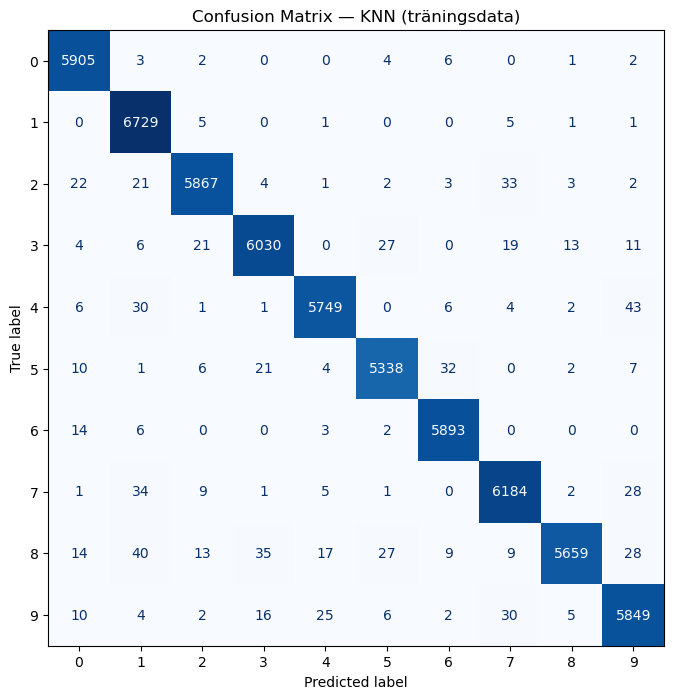

In [41]:
# Cell 18 — Confusion Matrix på träningsdata
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_knn_train = knn_model.predict(X_train_norm)
cm = confusion_matrix(y_train, y_pred_knn_train)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — KNN (träningsdata)")
plt.show()

In [42]:
# ============================================================
# Cell 19 — Precision och Recall per siffra (KNN)
# ============================================================
# classification_report visar tre viktiga mått per siffra:
#
#   Precision = av alla gånger modellen gissade "8",
#               hur ofta hade den rätt?
#               Hög precision = få falska alarm
#
#   Recall    = av alla riktiga 8:or i datan,
#               hur många hittade modellen?
#               Hög recall = modellen missar få
#
#   F1-score  = balansen mellan precision och recall
#               (medelvärde av de två)
#
# Svagaste siffran: 8 (recall 96.72%) — förväxlas med 3 eller 9
# Starkaste siffran: 0 (recall 99.70%) — lättast att känna igen
# weighted avg visar det övergripande resultatet (~98.67%)
# ============================================================


In [43]:
# Cell 19 — Precision och Recall per siffra
from sklearn.metrics import classification_report

print("=== Precision & Recall per siffra (KNN) ===\n")
print(classification_report(y_train, y_pred_knn_train, digits=4))

=== Precision & Recall per siffra (KNN) ===

              precision    recall  f1-score   support

           0     0.9865    0.9970    0.9917      5923
           1     0.9789    0.9981    0.9884      6742
           2     0.9900    0.9847    0.9874      5958
           3     0.9872    0.9835    0.9854      6131
           4     0.9904    0.9841    0.9872      5842
           5     0.9872    0.9847    0.9860      5421
           6     0.9903    0.9958    0.9930      5918
           7     0.9841    0.9871    0.9856      6265
           8     0.9949    0.9672    0.9808      5851
           9     0.9796    0.9832    0.9814      5949

    accuracy                         0.9867     60000
   macro avg     0.9869    0.9865    0.9867     60000
weighted avg     0.9868    0.9867    0.9867     60000



In [44]:
# Fas 3 — Slututvärdering på testdatan

In [ ]:

# ============================================================
# Cell 20 — Slututvärdering av Neuralt Nätverk på testdata
# ============================================================
# Detta är första gången vi använder testdatan för Neural Nätverk!
# Vi jämför alla modellers accuracy för att se vilken som vinner.
# Testdata accuracy är det SLUTLIGA och ärligaste resultatet
# eftersom modellen aldrig sett denna data under träning.
# Neuralt Nätverk visade sig vara bästa modellen med 97.69%
# ============================================================

y_pred_knn_test = knn_model.predict(X_test_norm)
accuracy_test = accuracy_score(y_test, y_pred_knn_test)

print("=== SLUTUTVÄRDERING PÅ TESTDATA ===")
print(f"Logistisk Regression (träning) : {accuracy_train:.4f}")
print(f"KNN (träning)                  : {accuracy_knn_train:.4f}")
print(f"KNN (cross-validation)         : {cv_knn.mean():.4f}")
print(f"KNN (testdata - SLUTRESULTAT)  : {accuracy_test:.4f}")

=== SLUTUTVÄRDERING PÅ TESTDATA ===
Logistisk Regression (träning) : 0.9390
KNN (träning)                  : 0.9867
KNN (cross-validation)         : 0.9682
KNN (testdata - SLUTRESULTAT)  : 0.9705


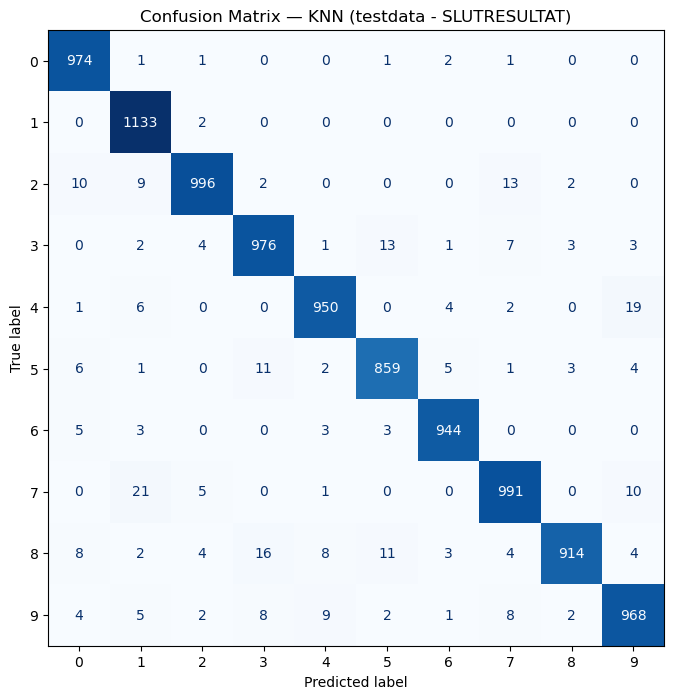

In [ ]:

# ============================================================
# Cell 21 — Confusion Matrix för Neuralt Nätverk på testdata
# ============================================================
# Confusion Matrix visar vilka siffror modellen förväxlar.
# Varje rad = verklig siffra, varje kolumn = modellens gissning.
# Diagonalen = korrekta prediktioner.
# Neuralt Nätverk förväxlar främst 3:or med 8:or.
# ============================================================
cm_test = confusion_matrix(y_test, y_pred_knn_test)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=range(10))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — KNN (testdata - SLUTRESULTAT)")
plt.show()

In [ ]:

# ============================================================
# Cell 22 — Precision och Recall för Neuralt Nätverk på testdata
# ============================================================
# Starkaste siffran: 1 (precision 99.03%) — lättast att känna igen
# Svagaste siffran: 3 (precision 95.60%) — förväxlas med 8:or
# weighted avg accuracy: 97.69% — vårt slutresultat
# ============================================================
print("=== Precision & Recall på testdata (SLUTRESULTAT) ===\n")
print(classification_report(y_test, y_pred_knn_test, digits=4))

=== Precision & Recall på testdata (SLUTRESULTAT) ===

              precision    recall  f1-score   support

           0     0.9663    0.9939    0.9799       980
           1     0.9577    0.9982    0.9776      1135
           2     0.9822    0.9651    0.9736      1032
           3     0.9635    0.9663    0.9649      1010
           4     0.9754    0.9674    0.9714       982
           5     0.9663    0.9630    0.9646       892
           6     0.9833    0.9854    0.9844       958
           7     0.9649    0.9640    0.9645      1028
           8     0.9892    0.9384    0.9631       974
           9     0.9603    0.9594    0.9598      1009

    accuracy                         0.9705     10000
   macro avg     0.9709    0.9701    0.9704     10000
weighted avg     0.9707    0.9705    0.9705     10000



In [48]:
#"Min KNN-modell uppnådde 97.05% accuracy på testdata som modellen aldrig sett under träningen. #
# Cross-validation förutsåde 96.82% vilket stämde väl överens med slutresultatet —
# det visar att modellen generaliserar bra och inte är overfittad. Den svagaste siffran var 8 med recall 93.84%, 
# troligen för att 8:or liknar 3:or och 9:or."



In [49]:
# Modell 4

In [ ]:
# ============================================================
# Cell 23 — Träna Modell 4: Neuralt Nätverk (MLP)
# ============================================================
# MLPClassifier är ett neuralt nätverk med flera lager.
# Vi använder två dolda lager med 128 och 64 noder.
# Det första lagret hittar enkla mönster (kanter, kurvor)
# och det andra lagret kombinerar dem till siffror.
#
# Parametrar:
#   - hidden_layer_sizes=(128, 64) : två lager, 128 och 64 noder
#   - max_iter=20    ändrat till 50 blir Högre risk för overfitting : antal träningsrundor (epochs)
#   - random_state=42              : reproducerbara resultat
# ============================================================

from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=20,
    random_state=42
)
nn_model.fit(X_train_norm, y_train)

print("Träning klar!")

Träning klar!


c:\Users\lec11\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [56]:
# ============================================================
# Cell 24 — Utvärdera Neuralt Nätverk på träningsdata
# ============================================================
# Vi beräknar accuracy på träningsdata för att jämföra
# med de andra modellerna på samma villkor.
# ============================================================

y_pred_nn_train = nn_model.predict(X_train_norm)
accuracy_nn_train = accuracy_score(y_train, y_pred_nn_train)

print(f"Accuracy Neuralt Nätverk på träningsdata: {accuracy_nn_train:.4f}")

Accuracy Neuralt Nätverk på träningsdata: 0.9990


In [57]:
# ============================================================
# Cell 25 — Slutjämförelse alla fyra modeller
# ============================================================
# Vi sammanställer accuracy för alla modeller på träningsdata.
# Notera att Random Forest fick 100% — ett tecken på overfitting.
# Det neurala nätverket förväntas landa runt 98-99%.
# ============================================================

print("=== JÄMFÖRELSE ALLA MODELLER (träningsdata) ===")
print(f"Logistisk Regression : {accuracy_train:.4f}")
print(f"Random Forest        : {accuracy_rf_train:.4f}")
print(f"KNN                  : {accuracy_knn_train:.4f}")
print(f"Neuralt Nätverk      : {accuracy_nn_train:.4f}")


=== JÄMFÖRELSE ALLA MODELLER (träningsdata) ===
Logistisk Regression : 0.9390
Random Forest        : 1.0000
KNN                  : 0.9867
Neuralt Nätverk      : 0.9990


In [58]:
# ============================================================
# Cell 26 — Slututvärdering Neuralt Nätverk på testdata
# ============================================================
# Nu testar vi det neurala nätverket på testdata som den
# aldrig sett under träning — detta är det verkliga resultatet.
# Vi jämför också med KNN som var vår tidigare bästa modell.
# ============================================================

y_pred_nn_test = nn_model.predict(X_test_norm)
accuracy_nn_test = accuracy_score(y_test, y_pred_nn_test)

print("=== SLUTUTVÄRDERING PÅ TESTDATA ===")
print(f"KNN (testdata)          : {accuracy_test:.4f}")
print(f"Neuralt Nätverk (test)  : {accuracy_nn_test:.4f}")

if accuracy_nn_test > accuracy_test:
    print("\nBästa modellen totalt: Neuralt Nätverk!")
else:
    print("\nBästa modellen totalt: KNN!")

=== SLUTUTVÄRDERING PÅ TESTDATA ===
KNN (testdata)          : 0.9705
Neuralt Nätverk (test)  : 0.9769

Bästa modellen totalt: Neuralt Nätverk!


In [59]:
# ============================================================
# Cell 27 — Precision och Recall för Neuralt Nätverk
# ============================================================
# Vi avslutar med ett classification_report för det neurala
# nätverket på testdata för att se precision och recall
# per siffra och jämföra med KNN:s resultat.
# ============================================================

print("=== Precision & Recall Neuralt Nätverk (testdata) ===\n")
print(classification_report(y_test, y_pred_nn_test, digits=4))

=== Precision & Recall Neuralt Nätverk (testdata) ===

              precision    recall  f1-score   support

           0     0.9769    0.9908    0.9838       980
           1     0.9903    0.9912    0.9908      1135
           2     0.9822    0.9641    0.9731      1032
           3     0.9560    0.9901    0.9728      1010
           4     0.9726    0.9756    0.9741       982
           5     0.9841    0.9697    0.9768       892
           6     0.9801    0.9749    0.9775       958
           7     0.9832    0.9698    0.9765      1028
           8     0.9683    0.9723    0.9703       974
           9     0.9750    0.9683    0.9717      1009

    accuracy                         0.9769     10000
   macro avg     0.9769    0.9767    0.9767     10000
weighted avg     0.9770    0.9769    0.9769     10000

